<a href="https://colab.research.google.com/github/jacunda/POS-DATASCIENCE-IA/blob/main/MLOPS/Cliente_de_Concess%C3%A3o_de_Cr%C3%A9dito_com_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Orientações

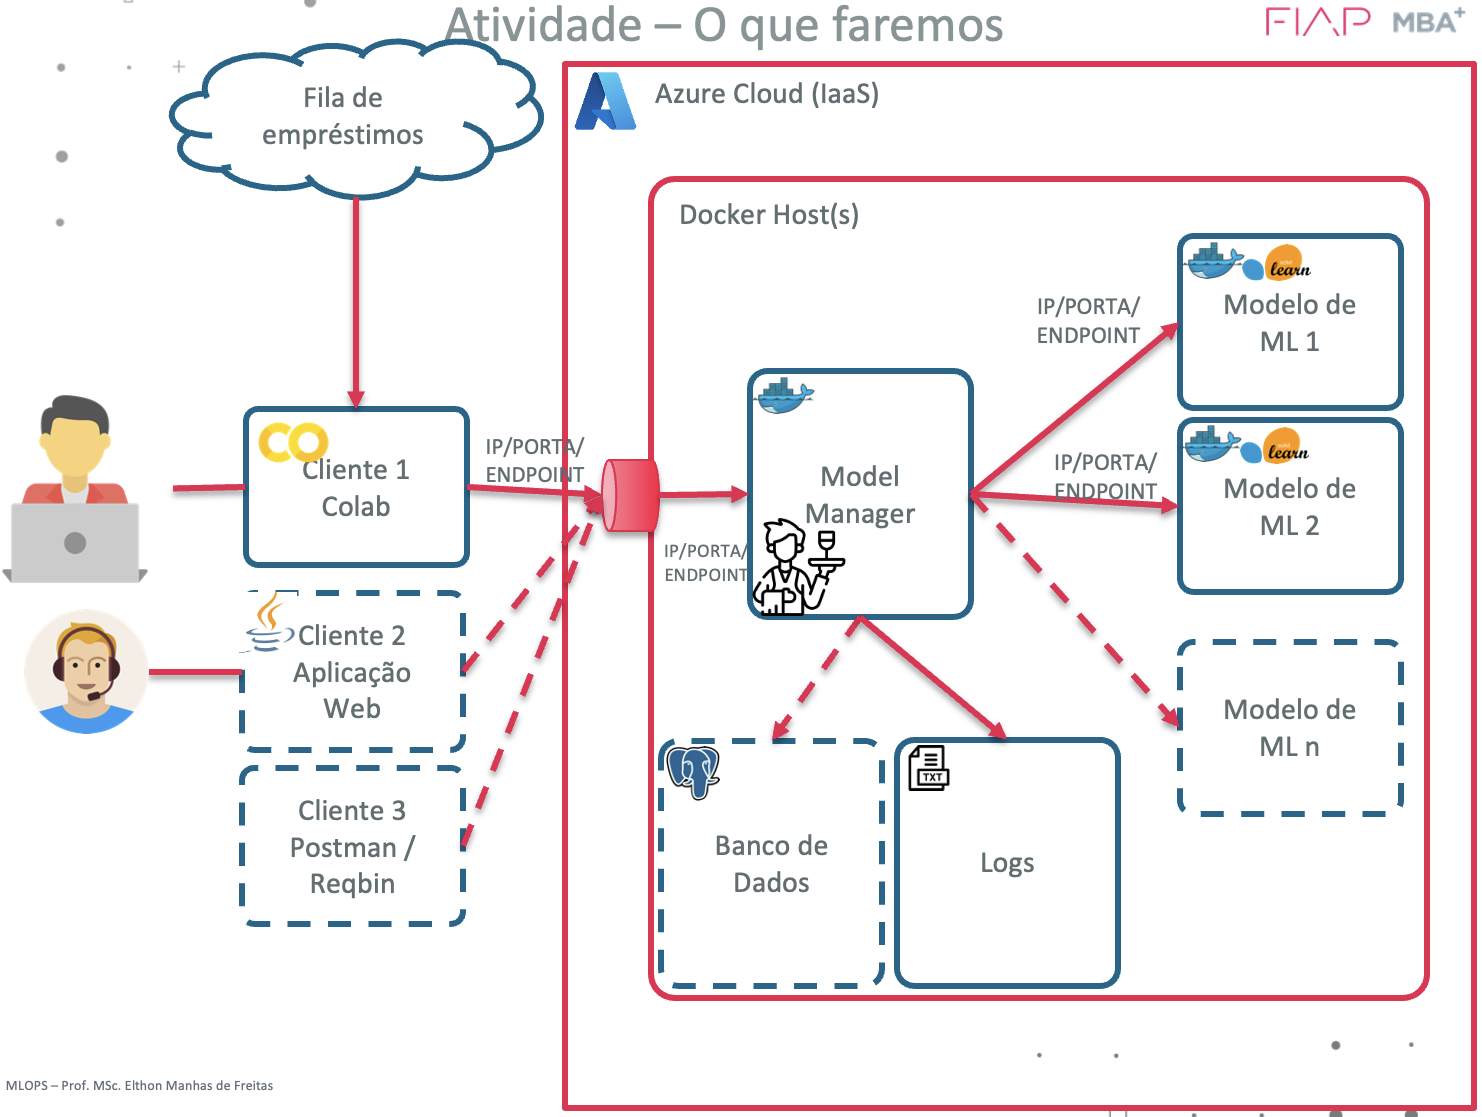

Você e os integrantes do teu grupo devem testar a chamada da sua solução composta pelos componentes acima.

Após fazer algumas chamadas, exportar este notebook (.ipynb) com as evidências com dados dos integrantes, e submeter pelo portal.

É preciso envio de arquivo zip contendo cada um .ipynb  por integrante.

# Configurações

In [ ]:
#@title Parâmetros da solução
#@markdown Informe a quantidade de clientes que devem ser analisados.
qtde_clientes = 8  #@param {type: "slider", min: 1, max: 10}

#@markdown Informe o IP do servidor de predição da sua solução:
my_server_ip = "40.70.132.26" #@param {type:"string"}

#@markdown Informe a porta do servidor de predição da sua solução, se nada foi alterado, deve ser 443:
my_server_port = "443" #@param {type:"string"}

#@markdown Informe o seu nome:
student_name = "Joao Vitor Azevedo Jacunda Santos" #@param {type:"string"}

#@markdown Informe o teu RM:
student_rm = "rm361721" #@param {type:"string"}


#@markdown Ah, e não se esqueça de executar esta célula!


In [ ]:
import requests
import pandas as pd
import json

# Obtenção dos empréstimos pendentes de análise

Vamos agora obter os clientes que estã precisand de empréstimo e exibí-los na tela

In [ ]:
url = "https://us-central1-emf-teacher.cloudfunctions.net/function-aulas-getclient?qtde={0}".format(qtde_clientes)
headers = {'Content-Type': 'application/json'}
response = requests.request("GET", url, headers=headers)
response_content = response.text.encode('utf8').decode()
clientes = pd.read_json(response_content)

/tmp/ipykernel_1716/853936079.py:5: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  clientes = pd.read_json(response_content)


In [ ]:
clientes

,nome,renda,idade,etnia,sexo,casapropria,outrasrendas,estadocivil,escolaridade
22947,"Michael, Chong",4921.025985,49.290398,0,0,1,1,1,3
41440,"Michael, Atkinson",4532.091693,18.656944,0,0,1,0,1,2
30649,"Zain, al-Zahra",3159.033890,36.566255,1,0,1,1,0,3
7527,"Jasper, Johnson",3393.425809,44.935958,0,0,1,1,1,3


# Predição

O cliente agora será submetido a dois modelos de Machine Learning preparados para a análise.

In [ ]:
url = "http://{}:{}/predict".format(my_server_ip, my_server_port)
headers = {'Content-Type': 'application/json'}
conteudo = clientes.to_json()

## Modelo 1

In [ ]:
url_completa1 = url + f"?model=modelo01&aluno={student_name}&rm={student_rm}"
response01 = requests.request("POST", url_completa1, headers=headers, data=conteudo)
respostas01 = json.loads(response01.text.encode('utf8').decode())
respostas01

{'prediction': [0, 0, 0, 0],
 'proba': [[0.9753456605030818, 0.02465433949691821],
  [0.9422916666666666, 0.057708333333333334],
  [0.7203287987309522, 0.2796712012690477],
  [0.7203287987309522, 0.2796712012690477]]}

In [ ]:
df_01 = pd.Series(respostas01['prediction'], index = clientes.index, name="PredicaoML01")
df_01B = pd.Series(respostas01['proba'], index = clientes.index, name="PredicaoML01B")

## Modelo 2

In [ ]:
url_completa2 = url + f"?model=modelo02&aluno={student_name}&rm={student_rm}"
response02 = requests.request("POST", url_completa2, headers=headers, data=conteudo)
respostas02 = json.loads(response02.text.encode('utf8').decode())
respostas02

{'prediction': [0.0, 0.0, 0.02865329512893983, 0.0050200803212851405]}

In [ ]:
df_02 = pd.Series(respostas02['prediction'], index = clientes.index, name="PredicaoML02")

## Consolidado das respostas

In [ ]:
pd.DataFrame(clientes.loc[:,"nome"])\
    .merge(right= df_01, left_index=True, right_index=True)\
    .merge(df_01B, left_index=True, right_index=True)\
    .merge(df_02, left_index=True, right_index=True)

,nome,PredicaoML01,PredicaoML01B,PredicaoML02
22947,"Michael, Chong",0,"[0.9753456605030818, 0.02465433949691821]",0.000000
41440,"Michael, Atkinson",0,"[0.9422916666666666, 0.057708333333333334]",0.000000
30649,"Zain, al-Zahra",0,"[0.7203287987309522, 0.2796712012690477]",0.028653
7527,"Jasper, Johnson",0,"[0.7203287987309522, 0.2796712012690477]",0.005020


# Extra

Avalie as variáveis listadas a seguir, para melhor compreensão da solução:

- `url`
- `url_completa1`
- `url_completa2`
- `conteudo`
- `df_01`
- `df_01B`
- `df_02`
